## Exercise Project 1 -- Linear Regression
### Dataset: [NYC Housing Prices](https://www.kaggle.com/datasets/ishank2005/nyc-housing-prices-csv)


<br>

<br>

##### Shape: `34k rows, 19 columns`

##### Target Variable: `sale_price`

##### Method: `Linear Regression`

##### Extra Tools: `Mlflow`

##### Column Descriptions (Complete):

| Column        | Description |
|--------------|-------------|
| borough_x    | *Borough code associated with the property sale record, sourced from the NYC Citywide Rolling Sales dataset.* |
| block        | *NYC tax block identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| lot          | *NYC tax lot identifier for the property, used as part of the Borough–Block–Lot (BBL) system.* |
| sale_price   | *Recorded sale price of the property transaction in US dollars. Non-arm’s-length and invalid transactions have been removed.* |
| zip_code     | *ZIP code of the property as recorded in the sales transaction data.* |
| borough_y    | *Borough code associated with the property tax lot, sourced from the PLUTO building dataset.* |
| yearbuilt    | *Year in which the primary structure on the tax lot was originally constructed.* |
| lotarea      | *Total land area of the tax lot, measured in square feet.* |
| bldgarea     | *Total gross building floor area on the tax lot, measured in square feet.* |
| resarea      | *Portion of the building floor area used for residential purposes, measured in square feet.* |
| comarea      | *Total commercial floor area within the building, measured in square feet.* |
| unitsres     | *Number of residential housing units on the tax lot.* |
| unitstotal   | *Total number of units on the tax lot, including residential and non-residential units.* |
| numfloors    | *Number of floors in the primary building on the tax lot.* |
| latitude     | *Latitude coordinate of the property location, expressed in decimal degrees.* |
| longitude    | *Longitude coordinate of the property location, expressed in decimal degrees.* |
| landuse      | *Numeric land use category code describing the primary use of the property (e.g., residential, commercial, mixed-use).* |
| bldgclass    | *NYC building class code indicating the structural and usage classification of the property.* |
| building_age | *Age of the building in years at the time of sale, calculated as sale year minus year built.* |


<br>
<br>

<i> 

This is the main notebook for exercise project 1. The approach for this notebook was to have only <b>minimal comments and prioritize readability </b> (my initial version had way too much explanations. This is the TL:DR version).



---

### Code

In [536]:
# import 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from skfeature.function.similarity_based import fisher_score
import matplotlib.pyplot as plt
from sklearn import metrics
from sklearn.preprocessing import OneHotEncoder
import joblib

# Reading the dataframe and storing it.
df = pd.read_csv("datasets/nyc_housing.csv")
df.head(5)

,borough_x,block,lot,sale_price,zip_code,borough_y,yearbuilt,lotarea,bldgarea,resarea,comarea,unitsres,unitstotal,numfloors,latitude,longitude,landuse,bldgclass,building_age
0,1,400,11,280000,10009.0,MN,1900.0,2404.0,6875.0,6875.0,0.0,18.0,18.0,5.0,40.724415,-73.983891,2.0,C6,125.0
1,1,402,36,2000000,10009.0,MN,1900.0,1919.0,7810.0,6810.0,1000.0,8.0,10.0,5.0,40.724975,-73.981535,2.0,C4,125.0
2,1,402,60,3400000,10009.0,MN,1920.0,2150.0,6152.0,5352.0,800.0,8.0,9.0,5.0,40.725346,-73.983112,4.0,C7,105.0
3,1,404,42,4000000,10009.0,MN,1855.0,2369.0,6990.0,6990.0,0.0,10.0,10.0,5.0,40.727398,-73.980600,2.0,C4,170.0
4,1,372,55,655000,10009.0,MN,1920.0,5298.0,17990.0,17990.0,0.0,20.0,20.0,5.0,40.720621,-73.979534,2.0,C6,105.0


## Cleaning

|Step|Description|
|---|---|
|1|<bold style="background:yellow;color:black;"> Data Cleaning </bold>|
|2| Transformation|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|

<br>

<i>
In this section, we'll check for missing values, check for duplicates, drop some initial columns (multicollinearity) and check for isolated cases in the categorical columns.
</i>

#### Checking The Dataframe Shape

In [537]:
# Checking the amount of columns and rows.
df.shape


(34439, 19)

#### Handling Missing Values

In [538]:
# Checking for missing values
df.isna().sum()

# A small amount of rows have missing values. 
# Getting rid of all the NaN will be trivial 200/34000 = .5% of the data. Not timeseries, so it's fine.

borough_x         0
block             0
lot               0
sale_price        0
zip_code         16
borough_y         0
yearbuilt         0
lotarea           0
bldgarea          0
resarea         188
comarea         188
unitsres          0
unitstotal        0
numfloors        43
latitude          6
longitude         6
landuse           3
bldgclass         0
building_age      0
dtype: int64

In [539]:
# Dropping nan values.
df = df.dropna()

#### Handling Duplicates

In [540]:
# Checking for duplicates
df.duplicated().value_counts()

# Some duplicates do exist. We can safely get rid of these.

False    33204
True       999
Name: count, dtype: int64

In [541]:
# Dropping the duplicate rows.
df = df.drop_duplicates()

#### Dropping Columns

<i>
In the cell below, we'll be dropping some of the columns which we know we won't be using. each column has a justification as a sidecomment. 
</i>



In [542]:
# Dropping co-dependent/high collinearity columns
df = df.drop(["borough_x",       # Related to borough_y
                'latitude',      # Probably just noise in the data. Definitely not linear.
                'longitude',     # Probably just noise in the data. Definitely not linear.
                'yearbuilt',     # This is co-dependent with `buildingage`
                'comarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'resarea',       # In this dataset: bldgarea = comarea + resarea. co-dependent.
                'lot',           # We have borough_y. This is too specific, you'd have distributions of 1 unit being in lot ABC, hardly statistical.
                'block',         # We have borough_y, too specific. We cant have 3 units in a block be a statistical weight for an ML model.
                'zip_code',      # Too specific, it'll affect distribution.
                'landuse',       # This is often co-dependent with bldgclass (D4 bldgclass = landuse 3 for example).      
], axis=1)

# `borough_y` and `bldglclass` is categorical, we'll convert this to numbers. 
df.head(3)


,sale_price,borough_y,lotarea,bldgarea,unitsres,unitstotal,numfloors,bldgclass,building_age
0,280000,MN,2404.0,6875.0,18.0,18.0,5.0,C6,125.0
1,2000000,MN,1919.0,7810.0,8.0,10.0,5.0,C4,125.0
2,3400000,MN,2150.0,6152.0,8.0,9.0,5.0,C7,105.0


#### Categorical Feature Isolated Case Elimination

<i>
In the cells below, we'll check the categorical column's value counts. If there isn't enough cases of a certain value, we drop it.
</i>

##### `bldgclass`

In [543]:
# In `bldgclass`, there are isolated cases there just isn't enough data
# to give a fair statistical weight to them.
value_counts = df['bldgclass'].value_counts().sort_values(ascending=True)
value_counts

# This eliminates any building classes that have less than 20 values. 
df = df[df['bldgclass'].isin(value_counts[value_counts >= 20].index)]

#### Categorical Feature Isolated Case Elimination

##### `borough_y`

In [544]:
# Let's check the other categorical feature, `borough_y`
df['borough_y'].value_counts()

# This seems ok! plenty of data to work with.

borough_y
QN    12619
BK     9532
SI     3842
MN     3717
BX     3221
Name: count, dtype: int64

#### Turning Categorical Columns into Numbers

<i> 
Now, we'll begin turning every possible feature into numbers.
</i>

In [545]:
# List of columns to convert to numbers.
categorical_columns = ["borough_y",  # Example values: MN, ME, BK
                       "bldgclass",  # Example values: C6, K4, C8
                       ]


# Converts columns into binary, separate columns.
for column in categorical_columns:
    encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
    one_hot_encoded = encoder.fit_transform(df[[column]]).astype(int)
    df = pd.concat([df.drop(columns=[column]), one_hot_encoded], axis=1)


df.head(3)

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_O2,bldgclass_O5,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9
0,280000,2404.0,6875.0,18.0,18.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,2000000,1919.0,7810.0,8.0,10.0,5.0,125.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
2,3400000,2150.0,6152.0,8.0,9.0,5.0,105.0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


---



### Transformation

|Step|Description|
|---|---|
|1| Data Cleaning|
|2| <bold style="background:yellow;color:black;">Transformation </bold>|
|3| ML Training & Metrics|
|4|Tester Row Values|
|5| Personal Analysis |
|6| Advanced Tasks|


####  Target Variable Outlier & Skew Elimination

<i>
Here, we'll check the column `sale_price` distribution and we'll fix it (I've tried many different transformations, truncation worked best for me.)
</i>

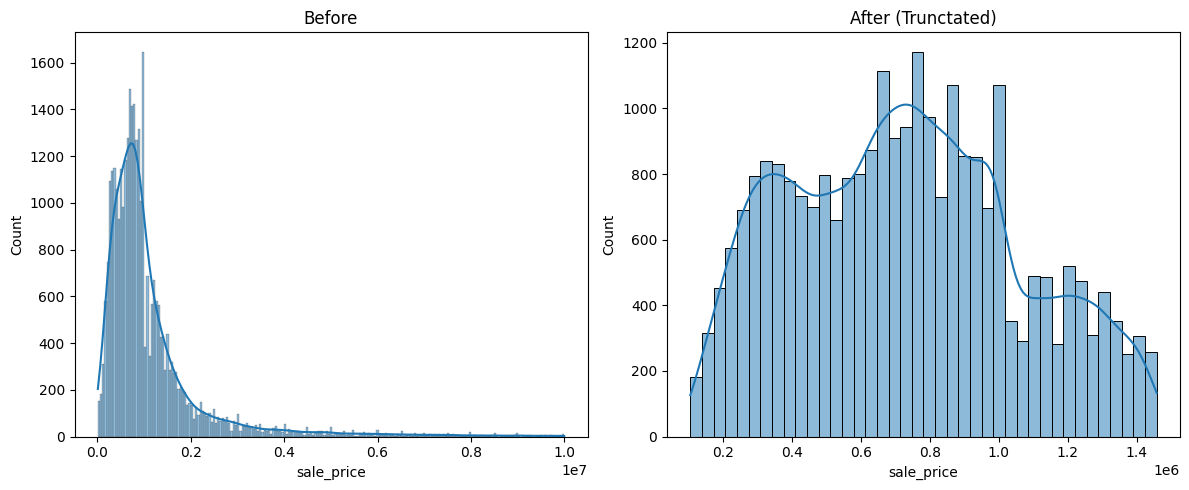

Rows left: 26016


In [546]:
from sklearn.preprocessing import PowerTransformer

# Target variable cutoffs 
y_trunc_floor = 0.01
y_trunc_ceiling = 0.80

# Creates three canvases for histplots to show my work.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))


# Histplot 0
sns.histplot(df, x='sale_price', ax=axes[0], kde=True)

# Truncating the Y variable.
df = df[
    (df["sale_price"] >= df["sale_price"].quantile(q=y_trunc_floor)) &
    (df["sale_price"] <= df["sale_price"].quantile(q=y_trunc_ceiling))
    ]

# Histplot 1
sns.histplot(df, x='sale_price', ax=axes[1], kde=True)

# Plot titles
axes[0].set_title("Before")
axes[1].set_title("After (Trunctated)")
plt.tight_layout()
plt.show()

# SANITY CHECK:
# Let's check how many rows we have left.
print(f"Rows left: {df.shape[0]}")

#### Checking Feature Distributions

<i>

We're going to make a copy of the dataframe and check the distributions. If anything needs to be fixed, well experiment on transformations <strong style='color:orange ; background-color:black;'> This won't affect the original dataset. We will apply whatever works after train/test splitting </strong>

</i>


<br>

### `unitsres`

##### Transformation

In [547]:
# Creating a new df. We're just doing this to see what transformations work.
check_df = df

Text(0.5, 1.0, 'Boxcox')

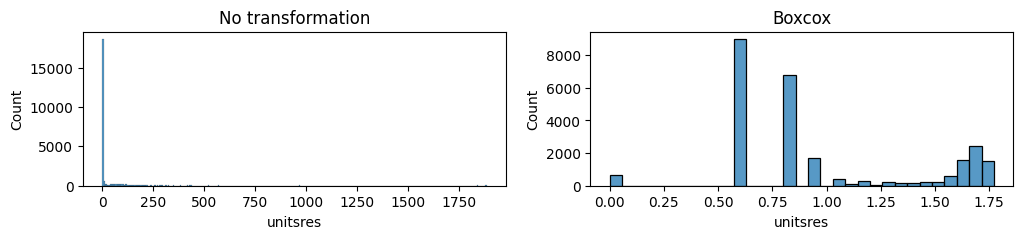

In [548]:
from scipy import stats
# Creates three canvases for histplots to show my work.
fig, axes = plt.subplots(1, 2, figsize=(12, 2))

# Histplot 1 
sns.histplot(check_df, x="unitsres", ax=axes[0])

# Using boxcox transformation
check_df["unitsres"], _ = stats.boxcox(check_df["unitsres"] + 1)

# Histplot2
sns.histplot(check_df, x="unitsres", ax=axes[1])

# Titles
axes[0].set_title("No transformation")
axes[1].set_title("Boxcox")


### `lotarea`

##### Transformation

Text(0.5, 1.0, 'Log transformation')

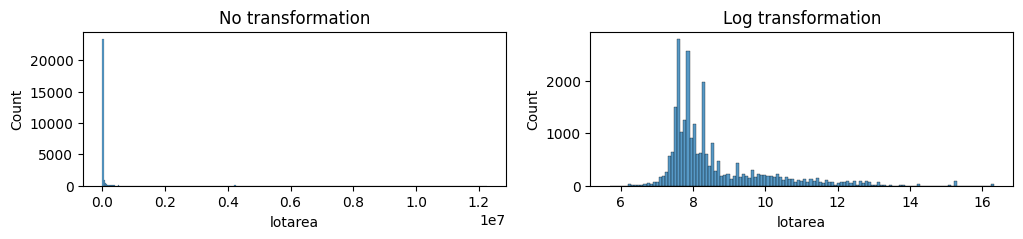

In [549]:
# Create a new canvas for subplots
fig, axes = plt.subplots(1, 2, figsize=(12,2))

# Histplot 1 (no changes)
sns.histplot(check_df, x='lotarea', ax=axes[0])

# Use log transformation to normalize
check_df['lotarea'] = np.log1p(check_df[['lotarea']])

# Histplot 2 (Log transformation)
sns.histplot(check_df, x='lotarea', ax=axes[1])

# Titles
axes[0].set_title("No transformation")
axes[1].set_title("Log transformation")

### `unitstotal`

##### Transformation

Text(0.5, 1.0, 'Yeojohnson')

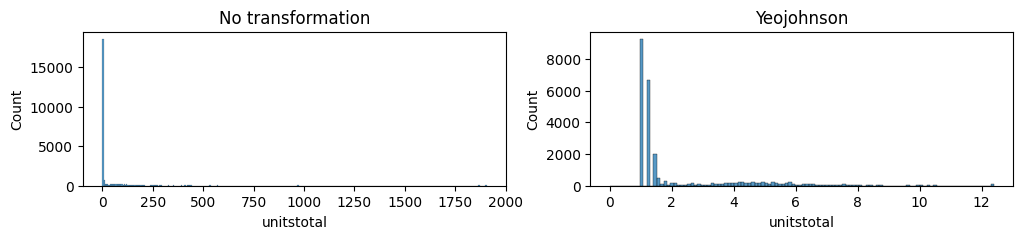

In [550]:
fig, axes = plt.subplots(1, 2, figsize=(12,2))

# Histplot 1 (no changes)
sns.histplot(check_df, x='unitstotal', ax=axes[0])

# Cuberoot transformation
check_df['unitstotal'] = np.cbrt(check_df['unitstotal'])

# Histplot 2 (Log Transformation)
sns.histplot(check_df, x='unitstotal', ax=axes[1])

# Titles
axes[0].set_title("No transformation")
axes[1].set_title("Yeojohnson")

### `bldgarea`

##### Transformation

Text(0.5, 1.0, 'Yeojohnson')

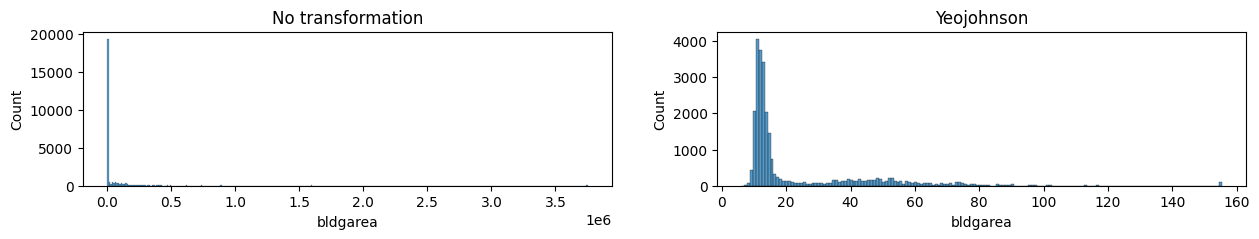

In [551]:
fig, axes = plt.subplots(1, 2, figsize=(15,2))

# Histplot 1 (no changes) 
sns.histplot(check_df, x='bldgarea', ax=axes[0])

# Cuberoot transformation
check_df['bldgarea'] = np.cbrt(check_df['bldgarea'])

# Histplot 2 (Yeojohnson Transformation) 
sns.histplot(check_df, x='bldgarea', ax=axes[1])

# Titles
axes[0].set_title("No transformation")
axes[1].set_title("Yeojohnson")


##### Fixing binomial distribution

### `building_age`

##### Quick Check

<Axes: xlabel='building_age', ylabel='Count'>

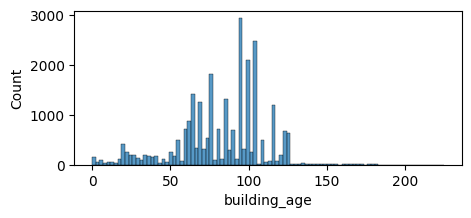

In [552]:
# Checking the distribution of `building_age`
plt.figure(figsize=(5,2))
sns.histplot(check_df, x='building_age')

# Seems ok!

---

### Selecting Features

#### Pearson Correlation

<i>
First, I'm narrowing down the number features. We currently have over 50 features. That's way too much to work with and I don't want to use any fancy modules. I will learn the basics before I use cool modules (LassoCV, RFE, etc).

In [553]:
# We're going to create a list of features that have the top 15
# highest pearson correlations. 

# Find the most correlated values. (using absolute value)
correlations = check_df.corr( method='pearson',numeric_only=True).sort_values(by='sale_price')
correlations = abs(correlations["sale_price"])

corr_df = pd.DataFrame(correlations).reset_index()

# Renaming the columns to make it tidy.
corr_df = corr_df.rename(columns={
    "index": "Feature",
    "sale_price": "Absolute Correlation Value"
})

# Filtering out `sale_price`, which naturally corrolates with itself.
corr_df = corr_df[corr_df["Feature"] != "sale_price"]
corr_df

,Feature,Absolute Correlation Value
0,lotarea,0.368103
1,unitstotal,0.362665
2,bldgclass_D4,0.347027
3,bldgarea,0.338611
4,unitsres,0.335563
...,...,...
59,bldgclass_A1,0.071247
60,bldgclass_B3,0.099258
61,bldgclass_C0,0.108361
62,bldgclass_B1,0.117643


#### Narrowing down feature candidates

<i>
We'll turn the best ones into a list. And keep narrowing them down.
</i>

In [554]:
# Take the 15 highest correlated features and wrap it as a list.
features_list = list(corr_df["Feature"].head(15))
features_list

# NOTE:
# This list is going to be which features we'll be using for our model. We'll narrow it down as we go.

['lotarea',
 'unitstotal',
 'bldgclass_D4',
 'bldgarea',
 'unitsres',
 'bldgclass_C6',
 'numfloors',
 'bldgclass_G4',
 'borough_y_BX',
 'borough_y_MN',
 'bldgclass_D1',
 'bldgclass_D3',
 'bldgclass_A6',
 'bldgclass_C7',
 'bldgclass_A8']

### Fisher Score

<i>
As far as I understand, Fisher score is used for categorical relationship testing. (I've done this a couple times in my business admin thesis using SPSS).

<br>
<br>

<b>Brief Explanation: </b>

Fisher score takes each feature and looks at it's feature-classes (ie: red, blue, green when the column is: Color). Then, it takes the mean and variance for each feature-class between the target variable (ie: fruits).
When it's done, it compares the statistics. The higher the separation between these statistics, the better the score.

<b>TLDR (Caveman-talk)</b>: 

Caveman look at color column. Caveman look at fruits column. Caveman see what color show up for Apple, Banana, Cherry. Red mostly Apple, Yellow mostly Banana, Green mostly Banana. Very different? Big Fish score go up. Caveman happy.

<br>

[Source on Fisher Score](https://www.geeksforgeeks.org/machine-learning/fisher-score-for-feature-selection/)

<br>

Therefore --  It's not really used for Regressions. Let's use it anyways though to test out how it works.


c:\Users\kykis\Intro_ML\.venv\Lib\site-packages\skfeature\function\similarity_based\fisher_score.py:59: RuntimeWarning: divide by zero encountered in divide
  score = 1.0 / lap_score - 1


<Axes: >

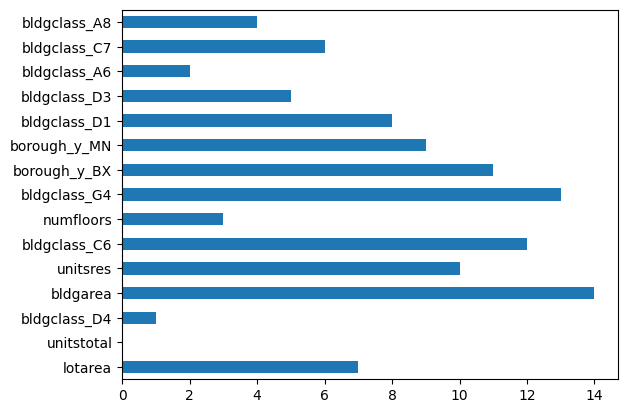

In [555]:
# First, take a sample
sample = check_df.sample(2000)

# Determine the features and target variable.
X = sample[features_list]
y = sample['sale_price']

# get the fisher's score rankings 
ranks = fisher_score.fisher_score(X.values, y.values)

# create a pandas DataFrame for easier interpretation
feat_importances = pd.Series(ranks, X.columns)
feat_importances.plot(kind='barh')

# Fisher's score studies the variance of the data -> statistical significance

### SelectKBest

<Axes: xlabel='Features', ylabel='Score'>

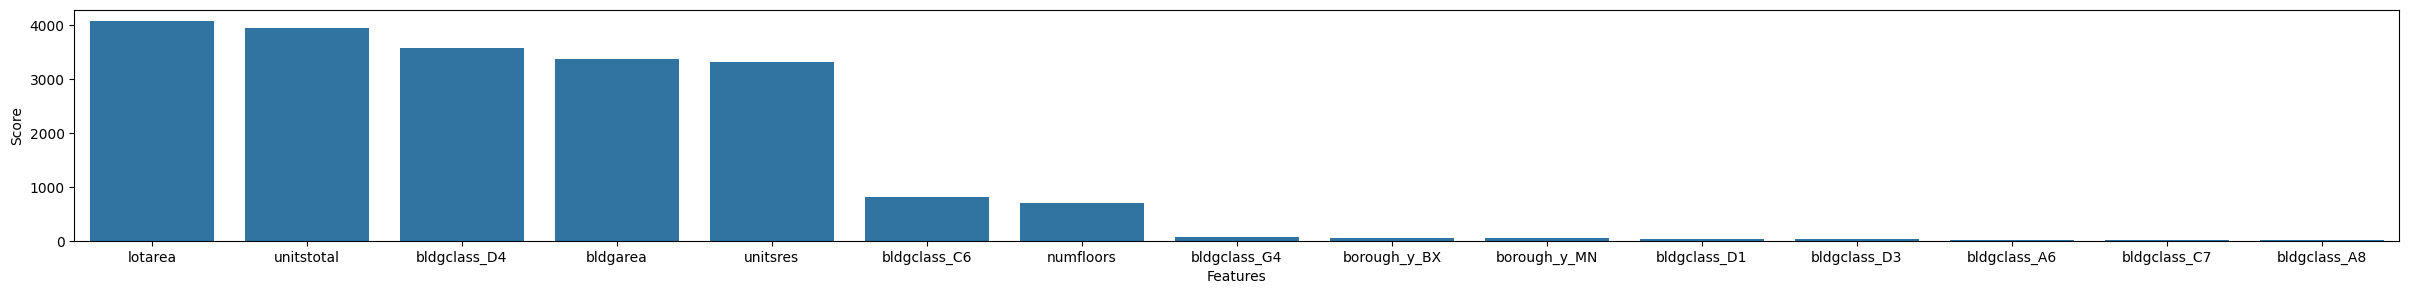

In [556]:
# -- SELECTKBEST --
# Basically, rank the features by statistical significance.
# Works with regression or classification

from sklearn.feature_selection import SelectKBest, f_regression

X = check_df[features_list]
y = check_df['sale_price']

# Convert all continuous variables to integer
X_cat = X.astype(int) 


# Use chi squared to help provide provide statistical
# significance metrix.
chi_2_features = SelectKBest(f_regression, k=10)

# Fit our data to the SelectKBest
best_features = chi_2_features.fit(X, y)

# Turn the features and columns into dataframes.
df_features = pd.DataFrame(best_features.scores_)
df_columns = pd.DataFrame(X.columns)

# Combine them and sort the values by 'Score'
f_scores = pd.concat([df_columns,df_features],axis=1)
f_scores.columns = ['Features','Score']
f_scores.sort_values(by='Score',ascending=False)

# Showing the scores
plt.figure(figsize=(30,3))
sns.barplot(f_scores, x="Features", y='Score')

<i>
Alright, we know what works and what doesn't. Let's remove a few more unneeded variables that clearly don't work according to these tests.
</i>

In [557]:
# Remove these features.
features_list.remove("bldgclass_A8")
features_list.remove("bldgclass_C7")
features_list.remove("bldgclass_D3")
features_list.remove("bldgclass_D1")

#### Checking for Feature Independence (via Correlation Heatmap)

<i>
Our last step for selecting these features is to be sure that these features are independent from one-another. 
</i>

<Axes: >

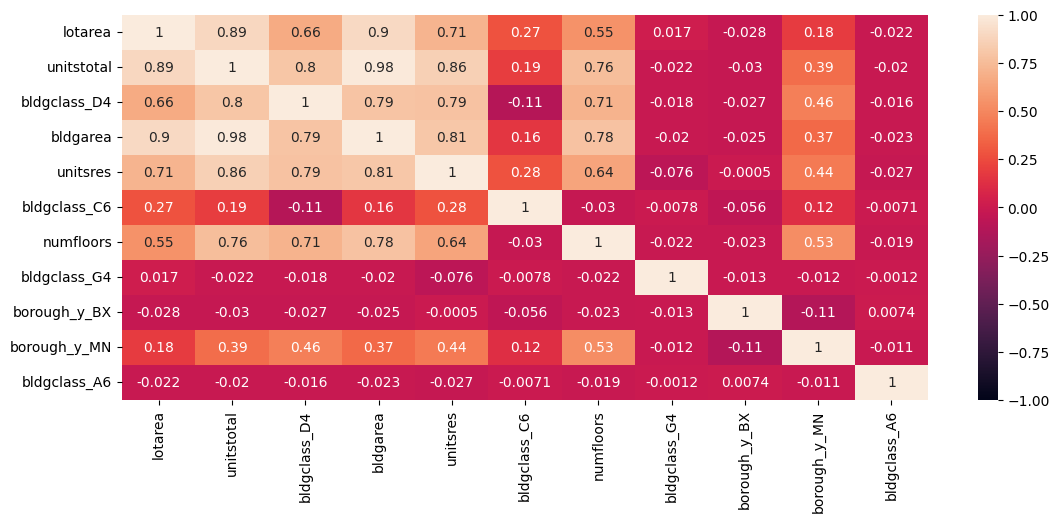

In [558]:
# Create a list correlation heatmap of all the feature candidates.
correlation = df[features_list].corr(numeric_only=True)
plt.figure(figsize=(13,5))
sns.heatmap(correlation, annot=True, vmin=-1, vmax=1)


#### 

In [ ]:
# I've tried getting rid of multicollinearity, but it made the model worse.

# features_list.remove("unitsres")
# features_list.remove("bldgarea")
# features_list

# It's probably because they're not COMPLETELY redundant. They're multicollinear. But not significantly enough not to be valuable.

---

### ML Implementation

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|<bold style="background:yellow;color:black;">ML Training & Metrics</bold>|
|4| Tester Row Values|
|5| Personal Analysis|
|6| Advanced Tasks|


#### `LinearRegression` ML Model Training & Logging

<i>
I train the model here and dump the model to a joblib that I place in the 'models' subdirectory inside of the project.
</i>






In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

# Constants (These are used to log the parameters in mlflow, that way I can remember what works)
XY_SPLIT = 0.3

# Defining dependent, independent variables.
X = df[features_list]
y = df['sale_price']

# train/test-split.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=XY_SPLIT, random_state=101)

# This will run all the transformations required to normalize the distribution.
# NOTE: I understand this is a different approach than was taught, but
# if I do it this don't have to deal with the transformation pre-processing 
# or the inversion.
# https://mahmoudyusof.github.io/blog/scikit-learn-pipelines


preprocessor = ColumnTransformer(transformers=[
    ('cbrt', FunctionTransformer(np.cbrt), ['bldgarea', "unitstotal"]),
    ('log', FunctionTransformer(np.log1p), ['lotarea']),
    ("boxcox", PowerTransformer(method="box-cox"), ["unitsres"]),
], remainder='passthrough')

# Runs the pipeline.
pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])

lm = pipeline.named_steps['model']

# Initalize and fit the model.
lm.fit(X_train, y_train)

# Find the intercept value of the regression.
intercept = lm.intercept_

# Create a list of coefficients for each feature.
coefs = lm.coef_

# Predict the data with the model.
predictions = lm.predict(X_test)

# Metrics recording (print is in the cell below)
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)

# Save the model using joblib
joblib.dump(lm, "models/ex1_main.pkl")


['models/ex1_main.pkl']

#### Metric & Parameter Prints


In [561]:
# -- METRICS RECORDING -- 
mae = metrics.mean_absolute_error(y_test, predictions)
mse = metrics.mean_squared_error(y_test, predictions)
rmse = np.sqrt(metrics.mean_squared_error(y_test, predictions))
r_sq = metrics.r2_score(y_test, predictions)


# -- PRINT METRICS --
print("METRICS")
print("--------------------------")
print("MAE")
print(f"{round(mae,2)} \n")
print("MSE")
print(f"{round(mse,2)} \n")
print("RMSE")
print(f"{round(rmse,2)} \n")
print('R-squared:')
print(f"{round(r_sq,2)} \n")

# -- PRINT PARAMETERS
print("PARAMETERS")
print("--------------------------")
print("Target Variable Truncation Amount:")
print(f"{y_trunc_floor, y_trunc_ceiling} \n")
print("X,Y Split:")
print(f"{XY_SPLIT}\n")

METRICS
--------------------------
MAE
227119.05 

MSE
82234944772.38 

RMSE
286766.36 

R-squared:
0.22 

PARAMETERS
--------------------------
Target Variable Truncation Amount:
(0.01, 0.8) 

X,Y Split:
0.3



#### Scatterplot Linearity Test

<i>
Here, we're looking for a line. I haven't quite gotten there yet.
</i>

<Axes: xlabel='sale_price'>

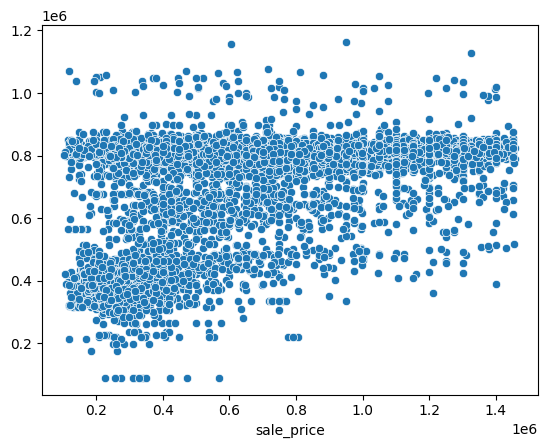

In [562]:
# If these values follow a line = good predictions
sns.scatterplot(x=y_test, y=predictions)

---

### Tester Row Values

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3| ML Training & Metrics|
|4| <bold style="background:yellow;color:black;">Tester Row Values</bold>|
|5| Personal Analysis |
|6| Advanced Tasks|

<br>

<i>
Here, we'll create an example prediction dictionary row. I can refer to this when I create my GUI.
</i>

In [564]:
tester_row = {
    'lotarea': 19000,
    'unitstotal': 20,
    'bldgclass_D4': 0,
    'bldgarea': 0,
    'unitsres': 25,
    'bldgclass_C6': 1,
    'numfloors': 7,
    'bldgclass_G4': 0,
    'borough_y_BX': 0,
    'borough_y_MN': 1,
    'bldgclass_A6': 0,
}

# Convert to pandas format
tester_row = pd.DataFrame([tester_row])

# Predict the result from the information above. (Note: this runs the transformations too.)
result = lm.predict(tester_row)[0]

# Print the result.
print(f"Predicted price for this home:")
print(f"$ {round(float(result), 2)}")



Predicted price for this home:
$ 10063678.64


---

### Personal Analysis

<br>

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|ML Training & Metrics|
|4| Tester Row Values|
|5|<bold style="background:yellow;color:black;"> Personal Analysis </bold>|
|6| Advanced Tasks|



#### Creating a Dataframe with `predicted_price` and `error_margin`

<i>
This is mostly used for myself. I'm creating a dataframe that easily lets us check the results in one dataframe. It's useful to have a DataFrame with the predictions and actuals all-in-one.
</i>

In [565]:
# Adding a column to the dataframe which predicted the price.
case_df = df
case_df['predicted_price'] = lm.predict(X).round(2)

# Creating an error margin column for the price for each row.
case_df["error_margin"] = abs(df["sale_price"] - df['predicted_price']).round(2)

case_df = case_df.sort_values("error_margin", ascending=False)

# Here, we can see some of the extreme cases with high error margins.
# NOTE: `error_margin` and `predicted_price` is at the end of the dataset
case_df

,sale_price,lotarea,bldgarea,unitsres,unitstotal,numfloors,building_age,borough_y_BK,borough_y_BX,borough_y_MN,...,bldgclass_O7,bldgclass_O8,bldgclass_S1,bldgclass_S2,bldgclass_S3,bldgclass_S4,bldgclass_S5,bldgclass_S9,predicted_price,error_margin
4039,1400000,11.835900,73.631723,1.733755,7.343420,6.0,73.0,0,0,0,...,0,0,0,0,0,0,0,0,294536.55,1105463.45
12299,1400000,10.518700,52.344118,1.685474,5.241483,6.0,109.0,1,0,0,...,0,0,0,0,0,0,0,0,390304.83,1009695.17
12302,1377500,10.518700,52.344118,1.685474,5.241483,6.0,109.0,1,0,0,...,0,0,0,0,0,0,0,0,390304.83,987195.17
23199,1350000,10.172025,42.682720,1.640079,4.272659,6.0,70.0,0,1,0,...,0,0,0,0,0,0,0,0,370797.06,979202.94
17609,1415000,9.380252,30.723168,1.541107,3.174802,4.0,123.0,1,0,0,...,0,0,0,0,0,0,0,0,438754.54,976245.46
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31525,825000,8.006701,12.690935,0.822112,1.259921,2.5,45.0,0,0,0,...,0,0,0,0,0,0,0,0,825030.20,30.20
29663,799000,7.601402,10.857670,0.575202,1.000000,2.0,90.0,0,0,0,...,0,0,0,0,0,0,0,0,798975.06,24.94
10068,835000,7.601402,14.422496,0.822112,1.259921,2.0,105.0,1,0,0,...,0,0,0,0,0,0,0,0,834985.70,14.30
10221,295000,12.845294,64.742969,1.724814,6.782423,3.0,75.0,0,0,0,...,0,0,0,0,0,0,0,0,294991.37,8.63


<h3>Post-Research Observations: </h3>

<i>
My observations are here. I condensed it so it's easier to read.
</i>

<br>
<br>


<div style="border: 3px dashed white; padding: 10px; box-sizing: border-box;">

<i>

I experimented by putting in a new model, `RandomForestRegressor` to see if it would give me improvements.
The results for `RandomForestRegressor` were notably better than `LinearRegression`. It was still a relatively low fit though. Here are the results:

</i>

<br>


|Random Forest Regressor Scatterplot (y-test, prediction)| Random Forest Regressor Performance Metrics|
|---|---|
|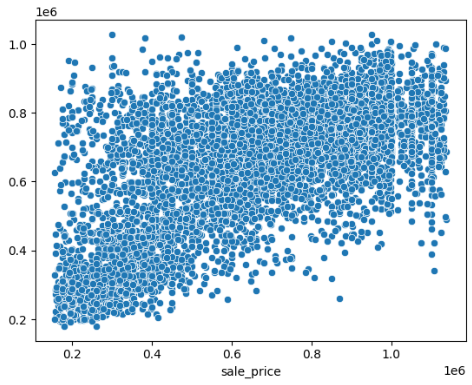|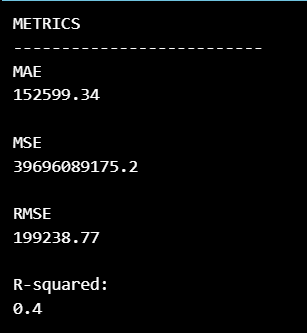|

I've done some research and some work related to WHY the performance metrics are so low with this particular dataset.

<br>
<i>
<h4><strong style='color:orange ; background-color:black;'>
</h4></strong></i>

<br>
<br>

### Reason 1</b>

<i>
<b>We're missing a key feature when it comes to NYC housing -- Maintenance contracts.</b>


 Just like in Finland,
many homes are part of housing associations or come with a maintenance contract, which affect the price HEAVILY. These maintenance contracts 
correlate negatively with the sales price of the home/apartment (higher maintenance cost, lower home price).
 Look at the example below so you get an idea of what I mean. Assume that these two homes are the same just with different maintenance contracts/costs.
But say that they have different maintenance contracts.

</i>

<b>Example:</b>

|House|House Price| Maintenance Cost/month|
|---|---|---|
|1| 400,000| 1,200|
|2| 1,000,000| 300|

<br>
<i>

`bldgclass_D4` is an apartment co-op building class, which are homes that are notorious for having high variance in these maintenance fees. But these actually should all have this variance to a big degree.

<br>
<br>

### Reason 2

<b> Variance. </b> We're dealing with lot prices, not home prices. Commercial AND Residential. Some locations had 12 floors or 110 buildings in a single lot. Many commercial plot classes really confused the data.
I imagine the optimal result would be to use different models for different classes of models.
Lots of categorical variables with lots of `value_counts`.

<br>
<br>
<br>

</i>

### Sources: 

<i>
If you'd like to see how I made reached this conclusion:
</i>
<br>
<br>

|Number|Source|
|---|---|
|1|[A forum discussing the maintenance cost & resale price](https://streeteasy.com/talk/discussion/40799-should-i-be-scared-away-by-high-maintenance-fee)
|2|[A paper that not-so-briefly discusses the complexity of the problem](https://arxiv.org/pdf/2007.01171)
|3|https://datasciencedojo.com/blog/binomial-distribution-in-machine-learning/|

</div>


---

## Advanced Tasks

|Step|Description|
|---|---|
|1| Data Cleaning |
|2| Transformation|
|3|ML Training & Metrics|
|4| Tester Row Values|
|5| Personal Analysis|
|6| <bold style="background:yellow;color:black;">Advanced Tasks </bold>|

<br>
<br>


<br>

<br>

## Adv. Task 1 -- Polynomial, Curve-fitting feature experimentation

## _[Link to Notebook](ex1_adv1.ipynb)_

<br>

---

## Adv. Task 2 -- Print the Poly-Linear Regression



|Task|Description|
|---|---|
|1|Experiment with polynomial and curve fitting features of `scikit-learn` with any dataset. Explain your findings in your Jupyter notebook, and analyze how useful they are.|
|2|<bold style="background:yellow;color:black;"> Write down the multiple linear regression formula of your model by using the `intercept-` and `coeff–` variables in your model `–object`.</bold>|
|3|You can also consider using other regressors like `CatBoostRegressor` which allows you to use other types of data than numbers without transformations. Write down your experiences with this regressor.|

This shouldn't be terribly hard, especially since the intercept and coefficient are given as 
`intercept-` and `coeff-`. 

In [566]:
features_list

['lotarea',
 'unitstotal',
 'bldgclass_D4',
 'bldgarea',
 'unitsres',
 'bldgclass_C6',
 'numfloors',
 'bldgclass_G4',
 'borough_y_BX',
 'borough_y_MN',
 'bldgclass_A6']

In [567]:
# The strategy will be to append a string with it's coefficients.
# IE: "Jere" + "my" = "Jeremy"

# First, we'll turn the coefficients into a list.
# This makes it easier to iterate over.
coefs_list = coefs.tolist()

# Second, we create a number translator for the variable subscripts.
#  This makes it look fancy.
sub = str.maketrans("0123456789", "₀₁₂₃₄₅₆₇₈₉")

# Third, we create the string variable, startying with ` y =`
regression_string = "y = "

# Fourth, initiate a loop which will append to the string above.
# The `enumerate` in the loop will let me call the VALUE and the INDEX.
# The index will be used to generate new variable names.
# The value, `coef`, will let us call the weight.
# IE: WeightX₁ + WeightX₂ WeightX₃ 
for  index, coef in enumerate(coefs_list):

    # Start with 1, not 0.
    index += 1
    # Translate the index to subscript.
    index = str(index).translate(sub)

    # Round the coefficient by 2
    coef = round(coef,2)

    # Add to the string the coefficient and variable name
    regression_string += f"{coef}x{index} + " 

#  Add the y-intercept at the end.
regression_string += str(intercept)

print(regression_string)


y = 435.19x₁ + -143329.77x₂ + -414279.34x₃ + 9256.8x₄ + 163080.58x₅ + -375550.91x₆ + 11793.66x₇ + -386288.12x₈ + -61381.53x₉ + 156514.73x₁₀ + -269822.06x₁₁ + 721097.8698895087


---

## Adv. Task 3 -- Using `CatBoostRegressor`

## _[Link to Notebook](ex1_adv3.ipynb)_